#Alumno: Octavio Quintero Flores
#Matricula: 266226
## Ejercicio D3

# Optimización del Tamaño de un Lote en Aprendizaje Automático

En el entrenamiento de modelos de aprendizaje automático, el tamaño del lote \( B \) influye directamente en el tiempo total de entrenamiento.

El tiempo total se modela como:

$$
T(B) = N(B)\cdot t(B)
$$

donde:

$$
N(B) \approx \frac{N_{total}}{B}
$$

$$
t(B) \approx t_0 + \frac{c\,N_{total}}{B^3}
$$

## Modelo matemático

Sustituyendo las expresiones:

$$
T(B) = \left(\frac{N_{total}}{B}\right)\left(t_0 + \frac{c\,N_{total}}{B^3}\right)
$$

Distribuyendo:

$$
T(B) = \frac{N_{total} t_0}{B} + \frac{c N_{total}^2}{B^4}
$$

## Derivada y punto crítico

Derivando respecto a \( B \):

$$
T'(B) = -\frac{N_{total} t_0}{B^2} - \frac{4c N_{total}^2}{B^5}
$$

Igualando a cero:

$$
-\frac{N_{total} t_0}{B^2} - \frac{4c N_{total}^2}{B^5} = 0
$$

Multiplicando por \( B^5 \):

$$
N_{total} t_0 B^3 + 4c N_{total}^2 = 0
$$

Despejando el valor óptimo:

$$
B^* = \left(\frac{4c\,N_{total}}{t_0}\right)^{1/3}
$$

## Verificación del mínimo

La segunda derivada de la función es positiva en \( B^* \), por lo tanto:

$$
T''(B) > 0
$$

Esto implica que el punto crítico corresponde a un **mínimo local**.

## Visualización

A continuación, se muestran dos ejemplos con distintos tamaños de dataset para observar el comportamiento de \( T(B) \) y verificar gráficamente el mínimo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def T(B, N_total, t0, c):
    return (N_total * t0)/B + (c * N_total**2)/(B**4)

def B_optimo(N_total, t0, c):
    return ((4 * c * N_total) / t0)**(1/3)

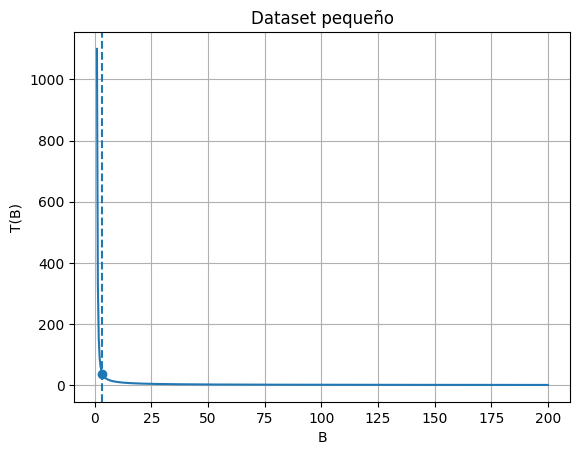

B óptimo: 3.4199518933533937


In [2]:
N_total = 1e4
t0 = 0.01
c = 1e-5

B = np.linspace(1, 200, 500)
T_values = T(B, N_total, t0, c)

B_star = B_optimo(N_total, t0, c)
T_star = T(B_star, N_total, t0, c)

plt.figure()
plt.plot(B, T_values)
plt.scatter(B_star, T_star)
plt.axvline(B_star, linestyle='--')

plt.title("Dataset pequeño")
plt.xlabel("B")
plt.ylabel("T(B)")
plt.grid()
plt.show()

print("B óptimo:", B_star)

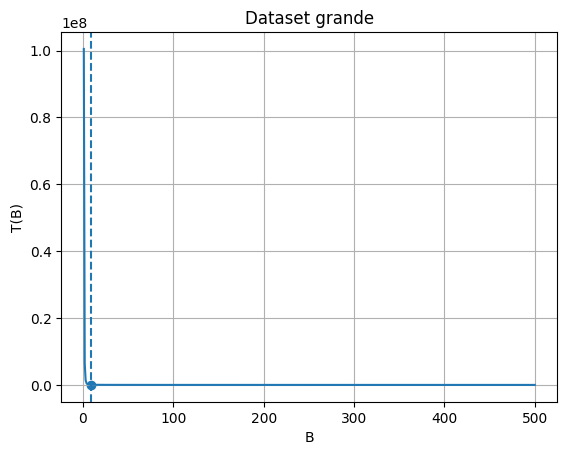

B óptimo: 9.283177667225557


In [3]:
N_total = 1e6
t0 = 0.5
c = 1e-4

B = np.linspace(1, 500, 500)
T_values = T(B, N_total, t0, c)

B_star = B_optimo(N_total, t0, c)
T_star = T(B_star, N_total, t0, c)

plt.figure()
plt.plot(B, T_values)
plt.scatter(B_star, T_star)
plt.axvline(B_star, linestyle='--')

plt.title("Dataset grande")
plt.xlabel("B")
plt.ylabel("T(B)")
plt.grid()
plt.show()

print("B óptimo:", B_star)

## Conclusión

El modelo muestra que el tiempo total de entrenamiento no disminuye indefinidamente al aumentar el tamaño del lote \( B \), ni tampoco al hacerlo muy pequeño.

Cuando \( B \) es pequeño:
- Se necesitan muchas iteraciones
- El entrenamiento es más lento

Cuando \( B \) es grande:
- Cada iteración es más costosa computacionalmente
- El tiempo total también aumenta

Por lo tanto, existe un punto intermedio óptimo que minimiza el tiempo total de entrenamiento.

Este valor óptimo está dado por:

$$
B^* = \left(\frac{4c\,N_{total}}{t_0}\right)^{1/3}
$$

En los ejemplos obtenidos:

- En el dataset pequeño, se obtuvo \( B^* \approx 3.41 \)
- En el dataset grande, se obtuvo \( B^* \approx 9.28 \)

Esto ocurre porque el valor óptimo depende directamente de \( N_{total} \):

- Cuando el número de datos es mayor, conviene usar lotes más grandes
- Esto reduce la cantidad de iteraciones necesarias

Sin embargo, el crecimiento no es lineal, sino que está controlado por una raíz cúbica, lo que hace que el aumento en \( B^* \) sea moderado.

En resumen, el tamaño óptimo del lote crece con el tamaño del dataset, pero de forma gradual, equilibrando eficiencia computacional y número de iteraciones.